# Parte 2 - Denoising con COVID
Hecho por Samuel Patiño y Nicolás Peña - IA Generativa UAO

Aca usamos el dataset de rayos X de COVID. Lo bajamos directo en Kaggle con kagglehub, le
metemos ruido gaussiano y entrenamos un autoencoder convolucional para limpiar.

La arquitectura base es la del cuaderno de la semana 5 del profesor. Sobre esa base corremos
seis estrategias distintas y las evaluamos con **dos niveles de ruido**:

- 0.5, que es el valor que trae el snippet del enunciado.
- 0.1, que es el que usa el repositorio de anushkayadav sobre CIFAR-10.

La idea es comparar en igualdad de condiciones y ver cuanto depende el resultado de que tan
violento sea el ruido. Al final mostramos las imagenes del modelo ganador de cada nivel.

En Kaggle: Settings > Accelerator > GPU y Internet ON, si no el download falla.

In [1]:
# revisamos GPU rapido
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# librerias basicas
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                                     BatchNormalization, Dropout, LeakyReLU, Dense,
                                     Flatten, Reshape, Add, Concatenate, Subtract, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array
%matplotlib inline
np.random.seed(42)
tf.random.set_seed(42)

# hiperparametros fijos para todos los experimentos
IMG = 64
EPOCHS = 30
BATCH = 32
LR = 0.001
LATENT = 256

# los dos niveles de ruido gaussiano que vamos a comparar
NIVELES = [0.5, 0.1]

In [3]:
# bajamos el dataset sin subir zip a mano
import kagglehub
base = kagglehub.dataset_download("pranavraikokte/covid19-image-dataset")
print("Path to dataset files:", base)
# el zip trae una carpeta intermedia (Covid19-dataset), hay que entrar a ella
DATA = os.path.join(base, "Covid19-dataset")
if not os.path.isdir(os.path.join(DATA, "train")):
    DATA = base  # por si kagglehub cambia la estructura
print("Usando:", DATA)
# miramos que carpetas trae
for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    if level < 3:
        print(root, "dirs:", dirs[:5], "files:", len(files))
    if level > 3:
        break

Path to dataset files: /kaggle/input/datasets/pranavraikokte/covid19-image-dataset
Usando: /kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset dirs: ['Covid19-dataset'] files: 0
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset dirs: ['test', 'train'] files: 0
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/test dirs: ['Normal', 'Viral Pneumonia', 'Covid'] files: 0
/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset/train dirs: ['Normal', 'Viral Pneumonia', 'Covid'] files: 0


In [4]:
# contamos cuantas hay por clase para el informe
import pathlib
for split in ["train", "test"]:
    print(split)
    for clase in sorted(os.listdir(os.path.join(DATA, split))):
        n = len(os.listdir(os.path.join(DATA, split, clase)))
        print(" ", clase, n)

train
  Covid 111
  Normal 70
  Viral Pneumonia 70
test
  Covid 26
  Normal 20
  Viral Pneumonia 20


(251, 64, 64, 3) (66, 64, 64, 3) ['Covid', 'Normal', 'Viral Pneumonia']


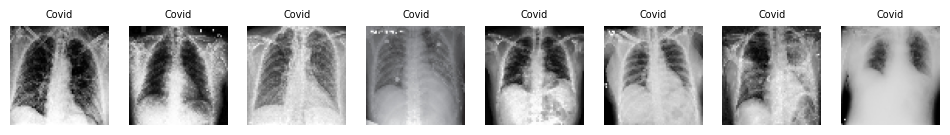

In [5]:
# cargamos todo a 64x64 en rgb para reusar la arquitectura
# son grises pero las pedimos en rgb asi quedan de 64x64x3 como pide la parte 0
IMG = 64
def cargar(split):
    xs, ys, clases = [], [], sorted(os.listdir(os.path.join(DATA, split)))
    mapa = {c:i for i,c in enumerate(clases)}
    for c in clases:
        carpeta = os.path.join(DATA, split, c)
        for f in os.listdir(carpeta):
            p = os.path.join(carpeta, f)
            try:
                img = load_img(p, target_size=(IMG, IMG), color_mode="rgb")
                xs.append(img_to_array(img) / 255.0)
                ys.append(mapa[c])
            except:
                pass
    return np.array(xs, dtype="float32"), np.array(ys), clases
x_train, y_train, clases = cargar("train")
x_test, y_test, _ = cargar("test")
print(x_train.shape, x_test.shape, clases)
# mostramos 8 limpias
plt.figure(figsize=(12,3))
for i in range(8):
    ax = plt.subplot(1,8,i+1); plt.imshow(x_train[i]); plt.axis("off")
    ax.set_title(clases[y_train[i]], fontsize=7)
plt.show()

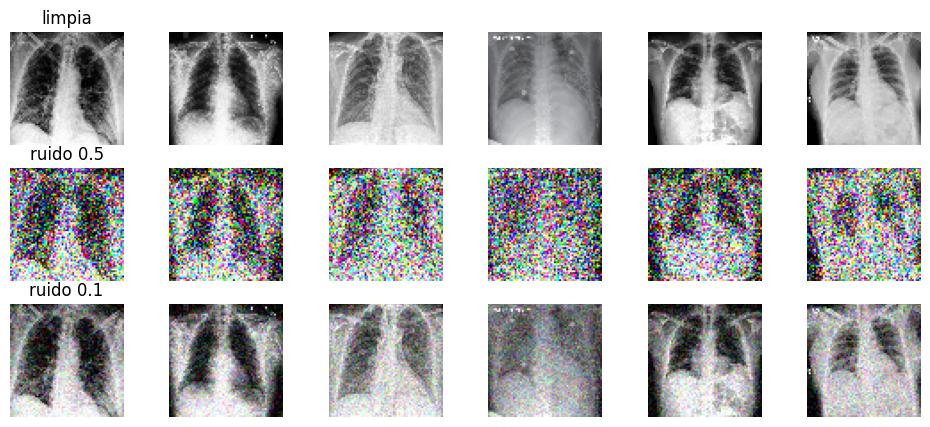

In [6]:
# ruido gaussiano que pide el examen, tal cual el snippet del PDF
# el factor entra como parametro porque lo vamos a variar
def add_noise(x, noise_factor=0.5):
    return np.clip(x + noise_factor * np.random.randn(*x.shape), 0., 1.)

# comparamos la misma imagen limpia contra los dos niveles de ruido
plt.figure(figsize=(12,5))
for i in range(6):
    ax = plt.subplot(3,6,i+1); plt.imshow(x_train[i]); plt.axis("off")
    if i==0: ax.set_title("limpia")
for k, nivel in enumerate(NIVELES):
    muestra_n = add_noise(x_train[:6], nivel)
    for i in range(6):
        ax = plt.subplot(3,6,(k+1)*6 + i + 1)
        plt.imshow(muestra_n[i]); plt.axis("off")
        if i==0: ax.set_title("ruido " + str(nivel))
plt.show()

## Metricas cuantitativas: PSNR, SSIM y MSE

Para saber de forma objetiva que tan bien limpio cada modelo usamos tres medidas numericas.

### MSE (Error Cuadratico Medio)

Es el promedio de las diferencias al cuadrado entre la imagen reconstruida y la original.
Mas bajo es mejor. Es la misma funcion que usamos como perdida durante el entrenamiento.
Su desventaja es que no es interpretable por si sola: un valor de 0.002 no dice mucho si no
hay un punto de comparacion.

### PSNR (Peak Signal-to-Noise Ratio)

Es el MSE expresado en decibeles para volverlo interpretable. Mas alto es mejor. Se calcula
como 20 * log10(MAX / sqrt(MSE)), donde MAX es el valor maximo posible del pixel. En nuestro
caso MAX = 1.0 porque normalizamos las imagenes dividiendo entre 255.

Guia para interpretarlo:

- menos de 20 dB: reconstruccion mala
- entre 20 y 30 dB: aceptable
- entre 30 y 40 dB: buena
- mas de 40 dB: excelente

### SSIM (Structural Similarity Index)

Mide si se conservo la estructura de la imagen (bordes, formas, texturas) y no solo si los
pixeles coinciden. Va de 0 a 1, donde 1 significa imagen identica. Es la medida que mejor se
acerca a lo que un humano diria que "se ve bien", porque combina tres comparaciones locales:
luminancia, contraste y estructura.

Guia para interpretarlo:

- 1.0: identica
- mayor a 0.90: muy buena
- entre 0.70 y 0.90: buena
- menor a 0.70: regular

### Como se usan en este cuaderno

Comparamos dos casos contra la misma referencia (la imagen limpia):

1. La imagen ruidosa contra la original: nos dice que tan degradada esta la entrada.
2. La imagen reconstruida contra la original: nos dice que tan bien limpio el modelo.

Lo importante no es el valor absoluto sino la diferencia entre ambos. Si el PSNR sube y el
SSIM se acerca a 1, el autoencoder esta eliminando ruido de verdad y no solamente suavizando
la imagen. Un modelo que solo suaviza baja el MSE pero tambien pierde detalle, y eso lo
delata un SSIM que no mejora.

### Detalle importante sobre SSIM

La funcion tf.image.ssim aplica un filtro de 11 por 11 pixeles, por lo que necesita imagenes
de al menos 11x11. Nosotros trabajamos con 64x64, asi que no hay problema. Si en algun
experimento se reduce la imagen a 8x8, esta funcion fallaria y habria que cambiar el tamaño
del filtro con el argumento filter_size o usar otra libreria.

In [7]:
# funciones para calcular las metricas
def calcular_metricas(a, b):
    """a = imagen a evaluar, b = imagen limpia de referencia. Ambas en [0,1]"""
    a = tf.convert_to_tensor(a, dtype=tf.float32)
    b = tf.convert_to_tensor(b, dtype=tf.float32)
    psnr = tf.image.psnr(a, b, max_val=1.0).numpy().mean()
    ssim = tf.image.ssim(a, b, max_val=1.0).numpy().mean()
    mse  = np.mean((a.numpy() - b.numpy()) ** 2)
    return psnr, ssim, mse

def mostrar_metricas(a, b, nombre):
    psnr, ssim, mse = calcular_metricas(a, b)
    print(f"{nombre:12s}  PSNR: {psnr:6.2f} dB   SSIM: {ssim:.4f}   MSE: {mse:.5f}")
    return psnr, ssim, mse

## Division de entrenamiento y validacion

El conjunto de train tiene 251 imagenes, que son pocas. Para elegir entre experimentos sin
contaminar el resultado final, separamos un 20 por ciento de esas 251 imagenes como conjunto
de validacion. El conjunto de test (66 imagenes) no se toca hasta el final: solamente se usa
para mostrar las imagenes de los modelos ganadores.

Si en cambio usaramos el test para elegir el mejor experimento, estariamos sobreajustando la
seleccion del modelo y el numero que reportemos en el informe no seria honesto.

Generamos una version ruidosa fija de validacion y de test **para cada nivel de ruido**, con
una semilla distinta a la del entrenamiento. Todos los experimentos de un mismo nivel se
evalúan contra exactamente ese mismo ruido, asi la comparacion entre ellos es justa.

Tambien medimos cuanto se degrada la imagen con cada nivel antes de que ningun modelo haga
nada. Ese numero es el piso del que partimos.

In [8]:
# separamos train en entrenamiento y validacion, manteniendo la proporcion de clases
x_tr_base, x_val_base, y_tr_base, y_val_base = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
print("entrenamiento:", x_tr_base.shape, " validacion:", x_val_base.shape)

# ruido fijo para evaluar, uno por cada nivel, siempre con la misma semilla
np.random.seed(0)
x_val_ruido = {n: add_noise(x_val_base, n) for n in NIVELES}
x_test_ruido = {n: add_noise(x_test, n) for n in NIVELES}
np.random.seed(42)

# cuanto se degrada la imagen con cada nivel, antes de que el modelo haga nada
print()
print("--- punto de partida: la imagen ruidosa contra la original ---")
for n in NIVELES:
    mostrar_metricas(x_val_ruido[n], x_val_base, "ruido " + str(n))

entrenamiento: (200, 64, 64, 3)  validacion: (51, 64, 64, 3)

--- punto de partida: la imagen ruidosa contra la original ---


I0000 00:00:1788718319.487413      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788718319.490705      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


ruido 0.5     PSNR:   9.16 dB   SSIM: 0.1177   MSE: 0.12131
ruido 0.1     PSNR:  20.47 dB   SSIM: 0.6130   MSE: 0.00899


## Constructores de arquitectura

Tenemos dos constructores, porque hay dos formas distintas de plantear el problema.

### construir_ae: el autoencoder del profesor

Es la arquitectura de la semana 5 con tres decisiones de diseño que podemos cambiar:

1. pooling: si es True usa MaxPooling2D como el profesor. Si es False usa una convolucion con
   stride 2. La idea viene del repositorio de Yadav, donde reportan que el max pooling puede
   ser perjudicial para tareas de restauracion porque descarta informacion espacial.

2. skip: si es "add" suma la conexion skip, como hace el profesor. Si es "concat" la concatena,
   que es el estilo U-Net usado por Sarang.

3. capas_extra: agrega convoluciones adicionales antes de comprimir, probando la idea de
   autoencoder apilado del paper de Nishio.

Y una cuarta que agregamos despues de ver los primeros resultados:

4. residual: si es True, la red no predice la imagen limpia sino **el ruido**, y la salida es
   la entrada menos ese ruido. Esto cambia el piso del modelo: si la red no aprende nada y
   predice cero, la salida es identica a la entrada. Ya no puede quedar por debajo.

### construir_dncnn: sin compresion

Este constructor es distinto: **no tiene pooling ni capa densa**. La imagen mantiene su
resolucion de 64x64 de punta a punta, pasando por varias convoluciones, y la salida tambien es
residual.

Es la idea de DnCNN (Zhang y otros, 2017) y coincide con lo que reporta Nishio: para
restauracion de imagenes conviene una red convolucional sin capas de pooling. Al no haber
cuello de botella, la red no esta obligada a descartar informacion para poder reconstruir.

### Por que agregamos el enfoque residual

En la primera corrida vimos algo que no cerraba: con ruido 0.5 el modelo mejoraba la entrada
hasta en 10 dB, pero con ruido 0.1 la empeoraba. La salida daba alrededor de 16 dB en ambos
casos, sin importar la calidad de la entrada.

Esa es la firma de un cuello de botella demasiado agresivo: el autoencoder comprime 12.288
valores (64x64x3) a solo 256, y ese techo limita la calidad de la reconstruccion. Si la entrada
esta peor que ese techo, el modelo mejora. Si esta mejor, el modelo empeora.

Con aprendizaje residual el piso pasa a ser la calidad de la entrada, no la del cuello de
botella.

In [9]:
# reduce el tamaño espacial a la mitad, con pooling o con stride segun el experimento
def bajar(x, filtros, pooling):
    if pooling:
        return MaxPooling2D()(x)
    return Conv2D(filtros, 3, strides=2, padding="same")(x)

def construir_ae(pooling=True, skip="add", capas_extra=0, dropout=0.3, residual=False):
    inputs = Input(shape=(IMG, IMG, 3))

    # encoder
    x = Conv2D(32, 3, activation="relu", padding="same")(inputs)   # 64x64x32
    x = BatchNormalization()(x)
    x = bajar(x, 32, pooling)                                      # 32x32x32
    x = Dropout(dropout)(x)

    skip_tensor = Conv2D(32, 3, padding="same")(x)                 # 32x32x32
    x = LeakyReLU()(skip_tensor)
    x = BatchNormalization()(x)
    x = bajar(x, 32, pooling)                                      # 16x16x32
    x = Dropout(dropout)(x)

    # capas adicionales para el experimento de autoencoder apilado
    for _ in range(capas_extra):
        x = Conv2D(64, 3, activation="relu", padding="same")(x)
        x = BatchNormalization()(x)

    x = Conv2D(64, 3, activation="relu", padding="same")(x)        # 16x16x64
    x = BatchNormalization()(x)
    x = bajar(x, 64, pooling)                                      # 8x8x64

    # espacio latente
    x = Flatten()(x)
    latent = Dense(LATENT, activation="relu", name="latent")(x)

    # decoder espejo
    x = Dense(8*8*64, activation="relu")(latent)
    x = Reshape((8, 8, 64))(x)
    x = Conv2DTranspose(64, 3, activation="relu", strides=(2,2), padding="same")(x)  # 16
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = Conv2DTranspose(32, 3, activation="relu", strides=(2,2), padding="same")(x)  # 32
    x = BatchNormalization()(x)
    x = Dropout(dropout)(x)
    x = Conv2DTranspose(32, 3, padding="same")(x)

    # conexion skip: suma como el profesor, o concatenacion estilo U-Net
    if skip == "add":
        x = Add()([x, skip_tensor])
    else:
        x = Concatenate()([x, skip_tensor])
    x = LeakyReLU()(x)
    x = BatchNormalization()(x)

    if residual:
        # predice el ruido y lo resta a la entrada
        ruido = Conv2DTranspose(3, 3, activation="linear", strides=(2,2), padding="same")(x)
        salida = Subtract()([inputs, ruido])
        salida = Lambda(lambda t: tf.clip_by_value(t, 0.0, 1.0))(salida)
    else:
        salida = Conv2DTranspose(3, 3, activation="sigmoid", strides=(2,2), padding="same")(x)

    return Model(inputs, salida)


def construir_dncnn(profundidad=6, filtros=64):
    """estilo DnCNN: sin pooling y sin capa densa. Predice el ruido y lo resta."""
    inputs = Input(shape=(IMG, IMG, 3))
    x = Conv2D(filtros, 3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU()(x)
    for _ in range(profundidad):
        x = Conv2D(filtros, 3, padding="same")(x)
        x = BatchNormalization()(x)
        x = LeakyReLU()(x)
    ruido = Conv2D(3, 3, activation="linear", padding="same")(x)
    salida = Subtract()([inputs, ruido])
    salida = Lambda(lambda t: tf.clip_by_value(t, 0.0, 1.0))(salida)
    return Model(inputs, salida)

## Definicion de los experimentos

Corremos ocho configuraciones con cada nivel de ruido. Las seis primeras son variantes de la
arquitectura del profesor; las dos ultimas son las que agregamos para atacar el problema del
cuello de botella.

- base_profe: arquitectura del profesor sin cambios. Es la linea base.
- sin_pooling: reemplaza MaxPooling2D por convolucion con stride 2.
- skip_concat: cambia la suma de la conexion skip por concatenacion.
- mas_profundo: agrega dos convoluciones extras al encoder.
- ruido_fresco: regenera el ruido en cada epoca, como aumento de datos.
- parches: entrena con recortes de 64x64 sacados de imagenes de 128x128.
- residual: la misma arquitectura base pero prediciendo el ruido en lugar de la imagen limpia.
- sin_compresion: estilo DnCNN, sin pooling ni capa densa, tambien con salida residual.

Los hiperparametros (epocas, batch, learning rate y tamaño del latente) son identicos en todos
los casos. Lo unico que cambia es la estrategia.

In [10]:
EXPERIMENTOS = [
    dict(nombre="base_profe",     pooling=True,  skip="add",    capas_extra=0, ruido_fresco=False, parches=False),
    dict(nombre="sin_pooling",    pooling=False, skip="add",    capas_extra=0, ruido_fresco=False, parches=False),
    dict(nombre="skip_concat",    pooling=True,  skip="concat", capas_extra=0, ruido_fresco=False, parches=False),
    dict(nombre="mas_profundo",   pooling=True,  skip="add",    capas_extra=2, ruido_fresco=False, parches=False),
    dict(nombre="ruido_fresco",   pooling=True,  skip="add",    capas_extra=0, ruido_fresco=True,  parches=False),
    dict(nombre="parches",        pooling=True,  skip="add",    capas_extra=0, ruido_fresco=False, parches=True),
    dict(nombre="residual",       pooling=True,  skip="add",    capas_extra=0, ruido_fresco=False, parches=False, residual=True),
    dict(nombre="sin_compresion", tipo="dncnn",  ruido_fresco=False, parches=False),
]
for e in EXPERIMENTOS:
    print(e["nombre"])

base_profe
sin_pooling
skip_concat
mas_profundo
ruido_fresco
parches
residual
sin_compresion


## Preparacion de los parches

Para el experimento de parches necesitamos imagenes mas grandes de las que podamos recortar.
Volvemos a cargar el conjunto de train pero a 128x128, y de cada imagen sacamos cuatro
recortes de 64x64 sin traslapar (las cuatro esquinas). Pasamos de 251 a 1004 muestras de
entrenamiento.

Esta idea viene del paper de Nishio, que entrena con parches de 28x28 y llega a 100,000 pares
a partir de pocas imagenes de tomografia.

In [11]:
# cargamos el train a 128x128 para poder recortar parches de 64x64
def cargar_grande(split, size=128):
    xs, ys = [], []
    clases = sorted(os.listdir(os.path.join(DATA, split)))
    mapa = {c: i for i, c in enumerate(clases)}
    for c in clases:
        carpeta = os.path.join(DATA, split, c)
        for f in os.listdir(carpeta):
            try:
                img = load_img(os.path.join(carpeta, f), target_size=(size, size),
                               color_mode="rgb")
                xs.append(img_to_array(img) / 255.0)
                ys.append(mapa[c])
            except Exception:
                pass
    return np.array(xs, dtype="float32"), np.array(ys)

x_tr_grande, _ = cargar_grande("train", 128)

# cuatro recortes de 64x64 por imagen, sin traslapar
crops = []
for im in x_tr_grande:
    for i in (0, 64):
        for j in (0, 64):
            crops.append(im[i:i+64, j:j+64])
x_tr_parches = np.array(crops, dtype="float32")
print("parches de entrenamiento:", x_tr_parches.shape)

parches de entrenamiento: (1004, 64, 64, 3)


## Ejecucion de los experimentos con MLflow

MLflow nos sirve para registrar cada corrida con sus parametros y sus metricas, de forma que
despues se puedan comparar de manera ordenada. Si por alguna razon MLflow no esta disponible
en el entorno, el codigo no falla: las metricas se guardan igual en una lista local y las
graficas se generan a partir de esa lista.

Corremos las seis estrategias dos veces, una por cada nivel de ruido. En total son doce
corridas. Cada una entrena con entrada ruidosa y salida limpia, usando MSE como funcion de
perdida tal como pide el enunciado, y al final calcula PSNR, SSIM y MSE sobre validacion.

En el caso de ruido_fresco el entrenamiento se hace epoca por epoca, generando un ruido nuevo
cada vez, porque el ruido fijo se memorizaria.

Por que dos niveles: el enunciado sugiere 0.5 pero la literatura trata el nivel de corrupcion
como un hiperparametro a calibrar, no como un valor fijo. Vincent y otros (2008) prueban
distintas fracciones segun el dataset. Correr ambos nos deja mostrar que la arquitectura
funciona y, al mismo tiempo, que el techo de calidad lo pone el ruido y no el modelo.

In [12]:
# MLflow no viene instalado en Kaggle, lo instalamos si hace falta
import subprocess, sys
try:
    import mlflow
    MLFLOW_OK = True
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mlflow"])
    try:
        import mlflow
        MLFLOW_OK = True
    except ImportError:
        MLFLOW_OK = False
print("MLflow disponible:", MLFLOW_OK)
if MLFLOW_OK:
    mlflow.set_experiment("covid-denoising")

resultados = []
modelos = {}

def correr_experimento(cfg, nivel):
    tf.keras.backend.clear_session()
    np.random.seed(42)
    tf.random.set_seed(42)

    # elegimos el constructor segun el tipo de experimento
    if cfg.get("tipo") == "dncnn":
        modelo = construir_dncnn(profundidad=cfg.get("profundidad", 6))
    else:
        modelo = construir_ae(pooling=cfg.get("pooling", True),
                              skip=cfg.get("skip", "add"),
                              capas_extra=cfg.get("capas_extra", 0),
                              residual=cfg.get("residual", False))
    modelo.compile(optimizer=Adam(learning_rate=LR), loss="mse")

    x_tr = x_tr_parches if cfg.get("parches", False) else x_tr_base
    x_val_n = x_val_ruido[nivel]
    nombre = f"{cfg['nombre']}_n{nivel}"

    hist = {"loss": [], "val_loss": []}
    if cfg.get("ruido_fresco", False):
        for _ in range(EPOCHS):
            xn = add_noise(x_tr, nivel)
            h = modelo.fit(xn, x_tr, epochs=1, batch_size=BATCH, shuffle=True,
                           validation_data=(x_val_n, x_val_base), verbose=0)
            hist["loss"] += h.history["loss"]
            hist["val_loss"] += h.history["val_loss"]
    else:
        h = modelo.fit(add_noise(x_tr, nivel), x_tr, epochs=EPOCHS, batch_size=BATCH,
                       shuffle=True, validation_data=(x_val_n, x_val_base), verbose=0)
        hist["loss"] = h.history["loss"]
        hist["val_loss"] = h.history["val_loss"]

    pred = modelo.predict(x_val_n, verbose=0)
    psnr, ssim, mse = calcular_metricas(pred, x_val_base)

    if MLFLOW_OK:
        with mlflow.start_run(run_name=nombre):
            mlflow.log_params({k: v for k, v in cfg.items() if k != "nombre"})
            mlflow.log_param("noise_factor", nivel)
            mlflow.log_param("epochs", EPOCHS)
            mlflow.log_param("batch_size", BATCH)
            mlflow.log_param("lr", LR)
            mlflow.log_metric("psnr", psnr)
            mlflow.log_metric("ssim", ssim)
            mlflow.log_metric("mse", mse)
            mlflow.log_metric("val_loss", hist["val_loss"][-1])

    resultados.append(dict(nombre=nombre, estrategia=cfg["nombre"], nivel=nivel,
                           psnr=psnr, ssim=ssim, mse=mse,
                           val_loss=hist["val_loss"][-1], hist=hist))
    modelos[nombre] = modelo
    print(f"{nombre:24s} PSNR {psnr:6.2f} dB   SSIM {ssim:.4f}   MSE {mse:.5f}")

# las ocho estrategias con cada uno de los dos niveles de ruido
for nivel in NIVELES:
    print()
    print("=== noise_factor =", nivel, "===")
    for cfg in EXPERIMENTOS:
        correr_experimento(cfg, nivel)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 13.9 MB/s eta 0:00:00
MLflow disponible: True


2026/09/06 18:12:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/06 18:12:29 INFO mlflow.store.db.utils: Updating database tables
2026/09/06 18:12:32 INFO mlflow.tracking.fluent: Experiment with name 'covid-denoising' does not exist. Creating a new experiment.



=== noise_factor = 0.5 ===


I0000 00:00:1788718368.112180     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


base_profe_n0.5          PSNR  17.57 dB   SSIM 0.5414   MSE 0.01857
sin_pooling_n0.5         PSNR  15.22 dB   SSIM 0.4609   MSE 0.03232
skip_concat_n0.5         PSNR  17.68 dB   SSIM 0.5409   MSE 0.01804
mas_profundo_n0.5        PSNR  17.33 dB   SSIM 0.5284   MSE 0.01958
ruido_fresco_n0.5        PSNR  17.39 dB   SSIM 0.5322   MSE 0.01948
parches_n0.5             PSNR  19.63 dB   SSIM 0.5691   MSE 0.01167
residual_n0.5            PSNR  10.92 dB   SSIM 0.1767   MSE 0.08139


2026-09-06 18:16:34.795906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-06 18:16:34.949216: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-06 18:16:38.785181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-06 18:16:38.932354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


sin_compresion_n0.5      PSNR  14.32 dB   SSIM 0.2832   MSE 0.03704

=== noise_factor = 0.1 ===
base_profe_n0.1          PSNR  16.69 dB   SSIM 0.5714   MSE 0.02253
sin_pooling_n0.1         PSNR  14.65 dB   SSIM 0.5163   MSE 0.03549
skip_concat_n0.1         PSNR  16.68 dB   SSIM 0.5827   MSE 0.02255
mas_profundo_n0.1        PSNR  16.78 dB   SSIM 0.5691   MSE 0.02207
ruido_fresco_n0.1        PSNR  15.34 dB   SSIM 0.5316   MSE 0.03033
parches_n0.1             PSNR  25.16 dB   SSIM 0.8190   MSE 0.00327
residual_n0.1            PSNR  20.54 dB   SSIM 0.6165   MSE 0.00885
sin_compresion_n0.1      PSNR  21.58 dB   SSIM 0.6631   MSE 0.00696


## Curvas de perdida por experimento

Graficamos la perdida de entrenamiento y de validacion de las seis estrategias, una figura por
cada nivel de ruido. Esto deja ver algo que las metricas finales no muestran: si un modelo
estaba todavia mejorando cuando se acabaron las epocas, o si por el contrario empezo a
sobreajustar, que se reconoce porque la perdida de validacion sube mientras la de
entrenamiento sigue bajando.

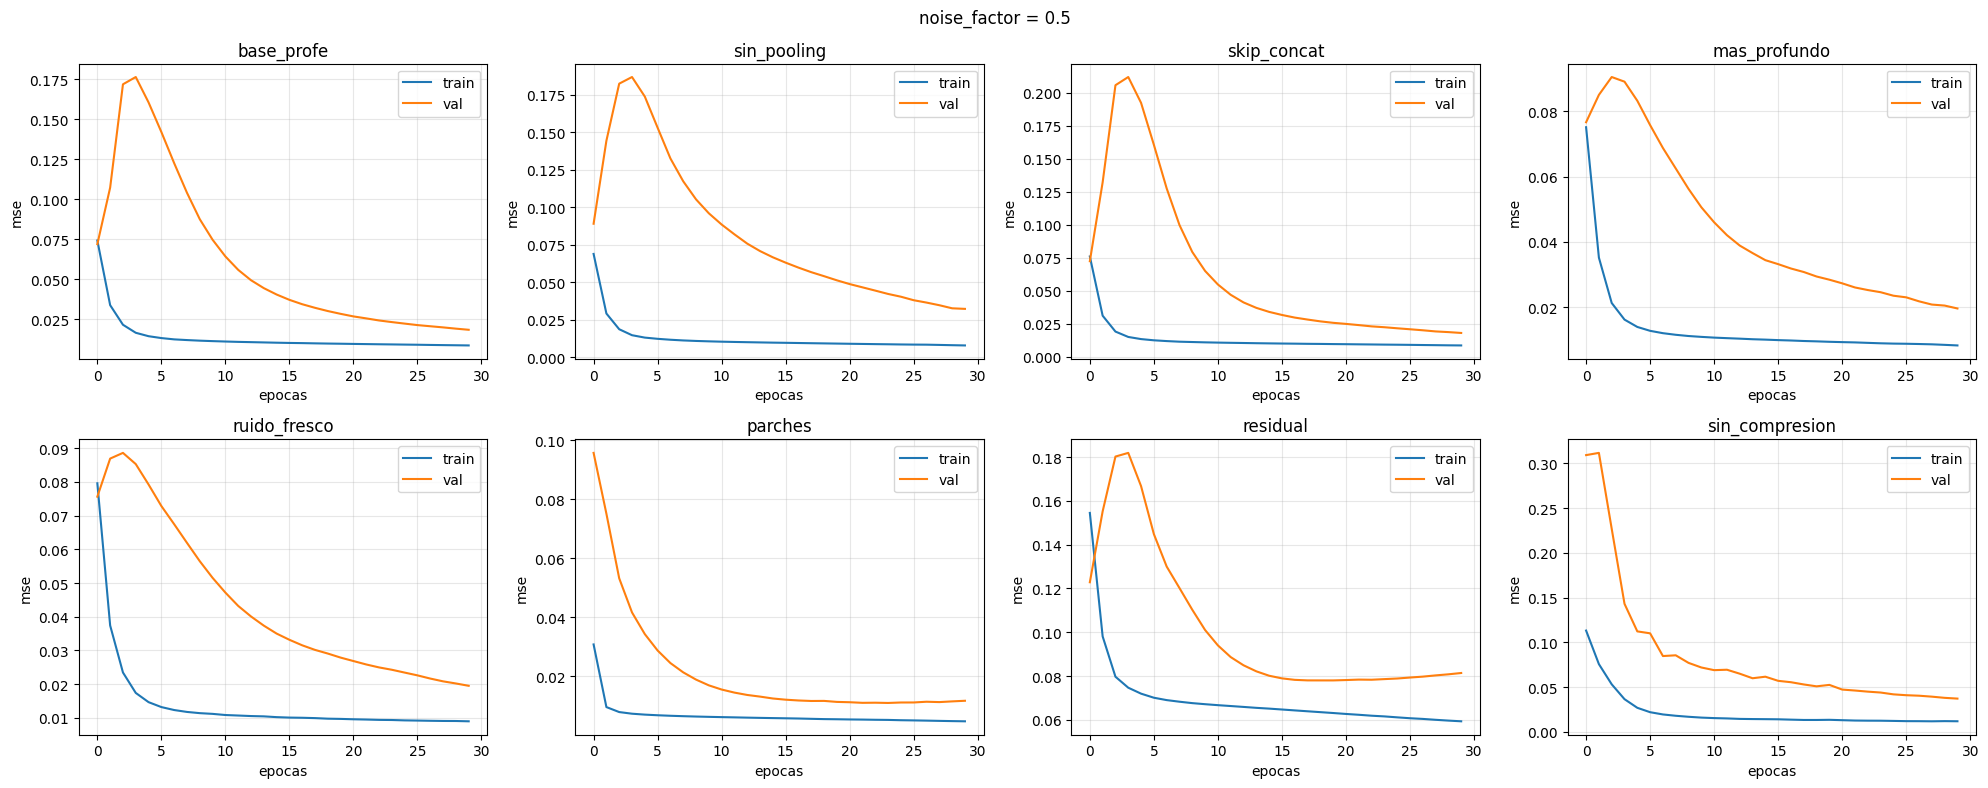

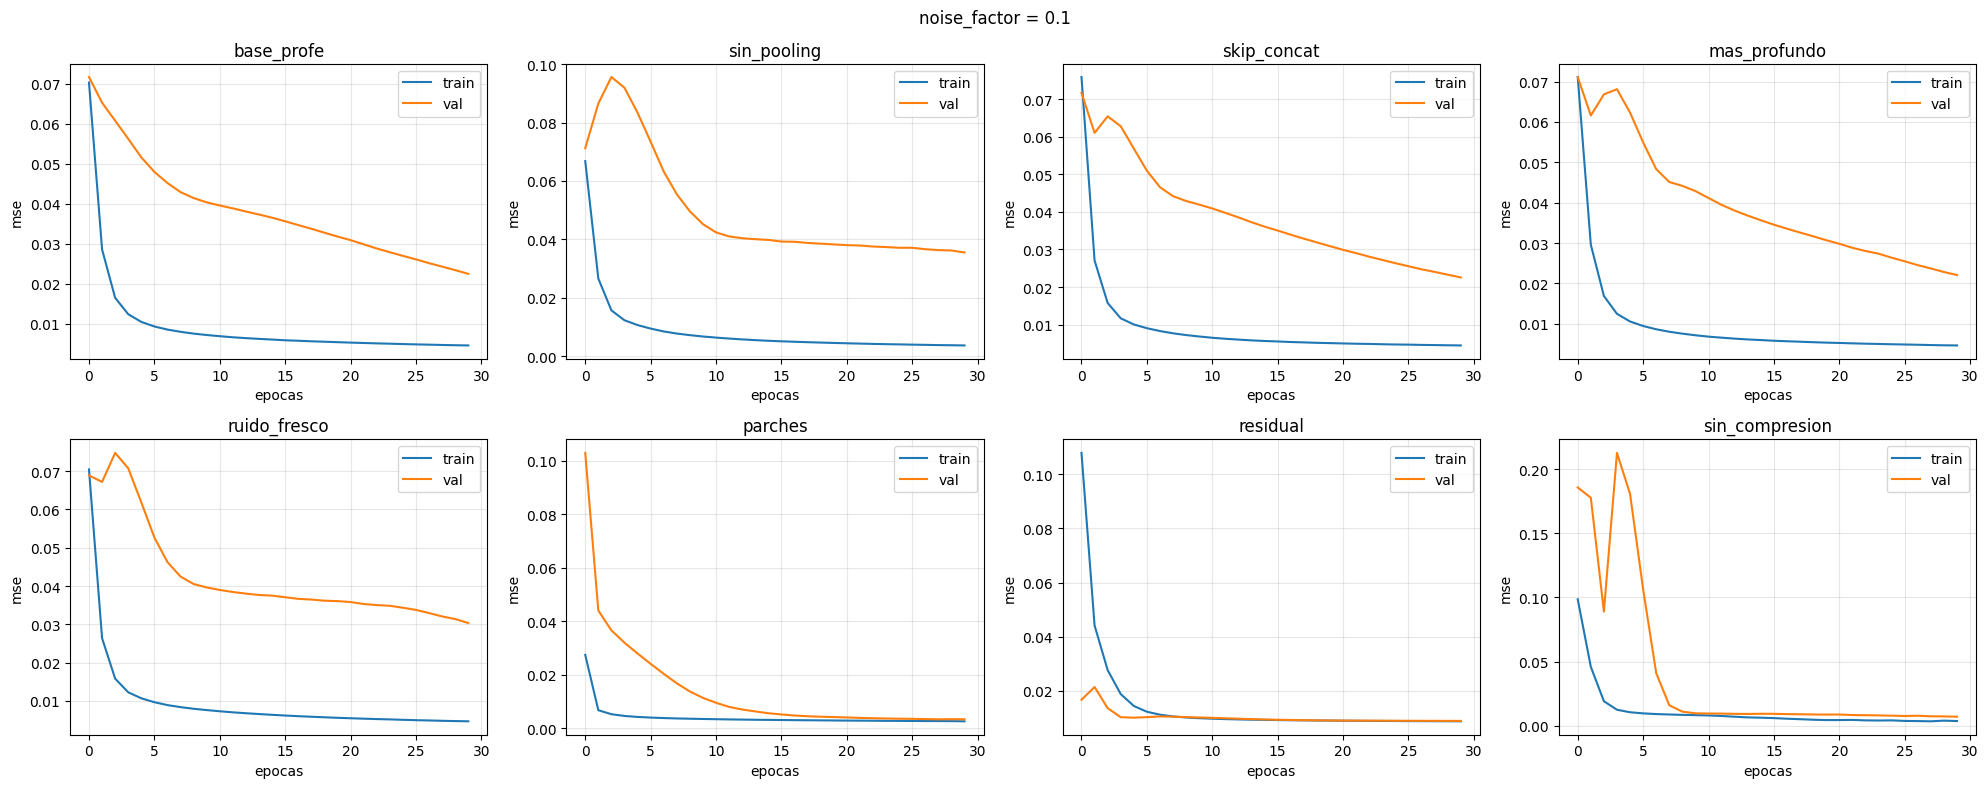

In [13]:
for nivel in NIVELES:
    bloque = [r for r in resultados if r["nivel"] == nivel]
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle("noise_factor = " + str(nivel))
    for ax, r in zip(axes.flat, bloque):
        ax.plot(r["hist"]["loss"], label="train")
        ax.plot(r["hist"]["val_loss"], label="val")
        ax.set_title(r["estrategia"])
        ax.set_xlabel("epocas")
        ax.set_ylabel("mse")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/curvas_ruido_{nivel}.pdf", format="pdf")
    plt.show()

## Comparacion de metricas

Agrupamos las barras por estrategia y ponemos los dos niveles de ruido uno al lado del otro.
Asi se ve de golpe cuanto cambia el resultado segun que tan violento sea el ruido.

El PSNR es el criterio principal para elegir: es la medida estandar en denoising y esta en
decibeles, asi que las diferencias se leen facil. El SSIM lo miramos como confirmacion, porque
un modelo que solamente suaviza la imagen puede bajar el MSE sin conservar la estructura, y
eso lo delata un SSIM que no mejora.

Como referencia, el repositorio de anushkayadav reporta sobre CIFAR-10 con ruido 0.1 un PSNR
de 24.83 y un SSIM de 0.868 para un autoencoder simple, y 28.25 con 0.938 para uno con
conexiones skip. Nuestros numeros no son directamente comparables porque el dataset y el
tamaño de imagen son otros, pero sirven para saber que orden de magnitud es realista.

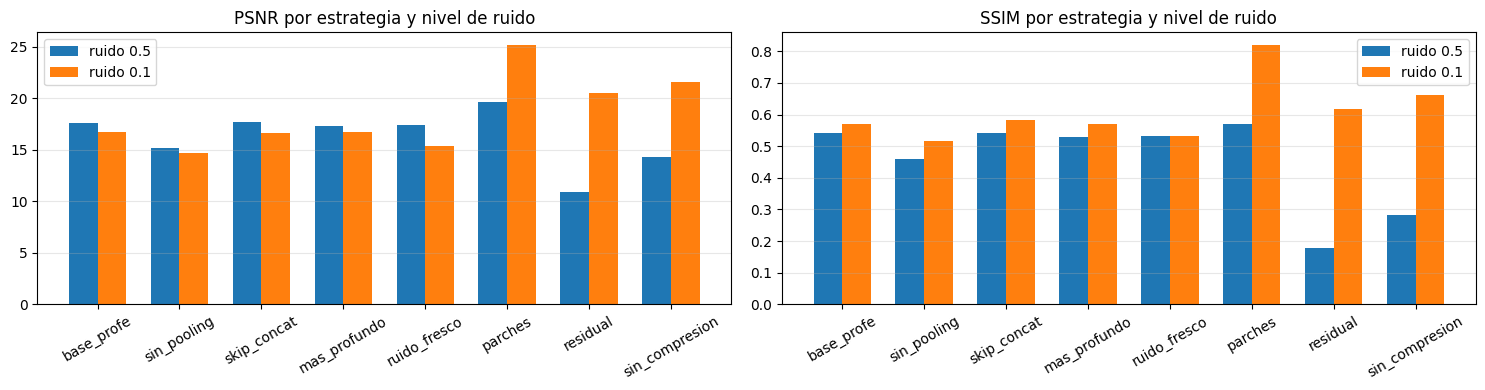

estrategia      ruido     PSNR     SSIM        MSE
base_profe        0.5    17.57   0.5414    0.01857
sin_pooling       0.5    15.22   0.4609    0.03232
skip_concat       0.5    17.68   0.5409    0.01804
mas_profundo      0.5    17.33   0.5284    0.01958
ruido_fresco      0.5    17.39   0.5322    0.01948
parches           0.5    19.63   0.5691    0.01167
residual          0.5    10.92   0.1767    0.08139
sin_compresion    0.5    14.32   0.2832    0.03704
base_profe        0.1    16.69   0.5714    0.02253
sin_pooling       0.1    14.65   0.5163    0.03549
skip_concat       0.1    16.68   0.5827    0.02255
mas_profundo      0.1    16.78   0.5691    0.02207
ruido_fresco      0.1    15.34   0.5316    0.03033
parches           0.1    25.16   0.8190    0.00327
residual          0.1    20.54   0.6165    0.00885
sin_compresion    0.1    21.58   0.6631    0.00696


In [14]:
estrategias = [e["nombre"] for e in EXPERIMENTOS]
x = np.arange(len(estrategias))
ancho = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, clave, titulo in [(axes[0], "psnr", "PSNR por estrategia y nivel de ruido"),
                          (axes[1], "ssim", "SSIM por estrategia y nivel de ruido")]:
    for k, nivel in enumerate(NIVELES):
        vals = [r[clave] for r in resultados if r["nivel"] == nivel]
        ax.bar(x + k*ancho - ancho/2, vals, ancho, label="ruido " + str(nivel))
    ax.set_xticks(x)
    ax.set_xticklabels(estrategias, rotation=30)
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/metricas_por_ruido.pdf", format="pdf")
plt.show()

print(f"{'estrategia':14s} {'ruido':>6s} {'PSNR':>8s} {'SSIM':>8s} {'MSE':>10s}")
for r in resultados:
    print(f"{r['estrategia']:14s} {r['nivel']:6.1f} {r['psnr']:8.2f} {r['ssim']:8.4f} {r['mse']:10.5f}")

## Seleccion del mejor modelo por nivel

Nos quedamos con la estrategia de mayor PSNR **dentro de cada nivel de ruido**, y mostramos las
imagenes de ambas ganadoras. No elegimos una sola porque los dos numeros responden preguntas
distintas: el de ruido 0.5 dice cuanto aguanta el modelo ante una degradacion extrema, y el de
ruido 0.1 dice que tan fiel es la reconstruccion cuando la degradacion es realista.

Una advertencia honesta: con unas 50 imagenes de validacion, diferencias de menos de medio
decibel no son significativas. Si dos estrategias empatan dentro de ese margen, la decision
deberia tomarse por criterio visual y por simplicidad del modelo, no por el numero.

In [15]:
mejores = {}
for nivel in NIVELES:
    m = max([r for r in resultados if r["nivel"] == nivel], key=lambda r: r["psnr"])
    mejores[nivel] = m
    print(f"ruido {nivel}: gano {m['estrategia']:14s} PSNR {m['psnr']:.2f} dB   SSIM {m['ssim']:.4f}")

ruido 0.5: gano parches        PSNR 19.63 dB   SSIM 0.5691
ruido 0.1: gano parches        PSNR 25.16 dB   SSIM 0.8190


## Resultados visuales de los modelos ganadores

Mostramos las imagenes de la ganadora de cada nivel, evaluadas sobre el conjunto de test, que
no se uso en ningun momento para elegir entre experimentos.

Para cada nivel va primero la tripleta original, ruidosa y reconstruida sobre diez imagenes, y
despues la grilla de 48 en el mismo formato que usa el profesor en su cuaderno de la semana 5.


=== noise_factor 0.5 - modelo parches ===
ruidosa       PSNR:   9.15 dB   SSIM: 0.1309   MSE: 0.12161
denoised      PSNR:  19.32 dB   SSIM: 0.5633   MSE: 0.01264


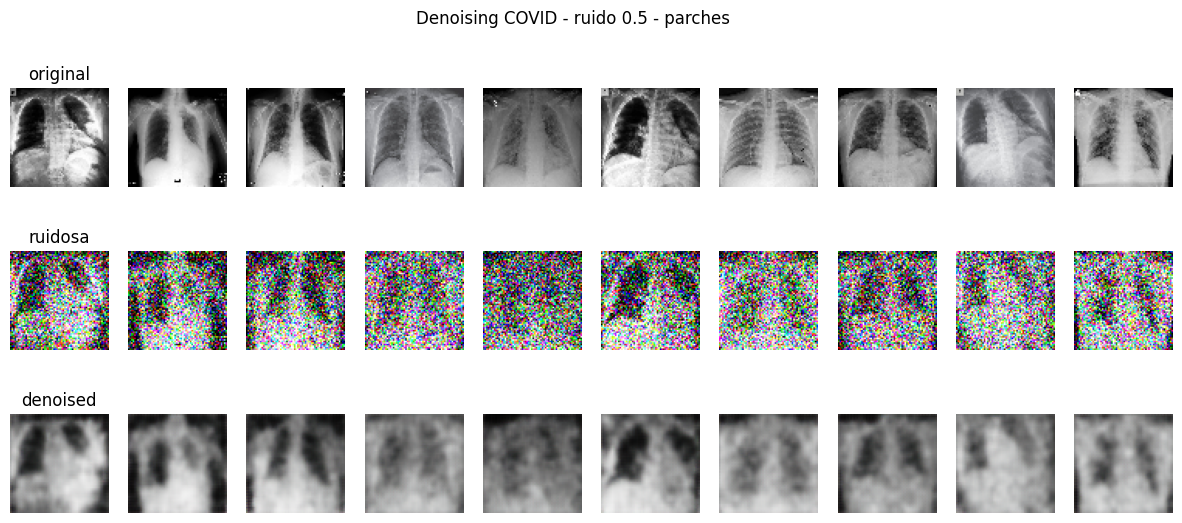

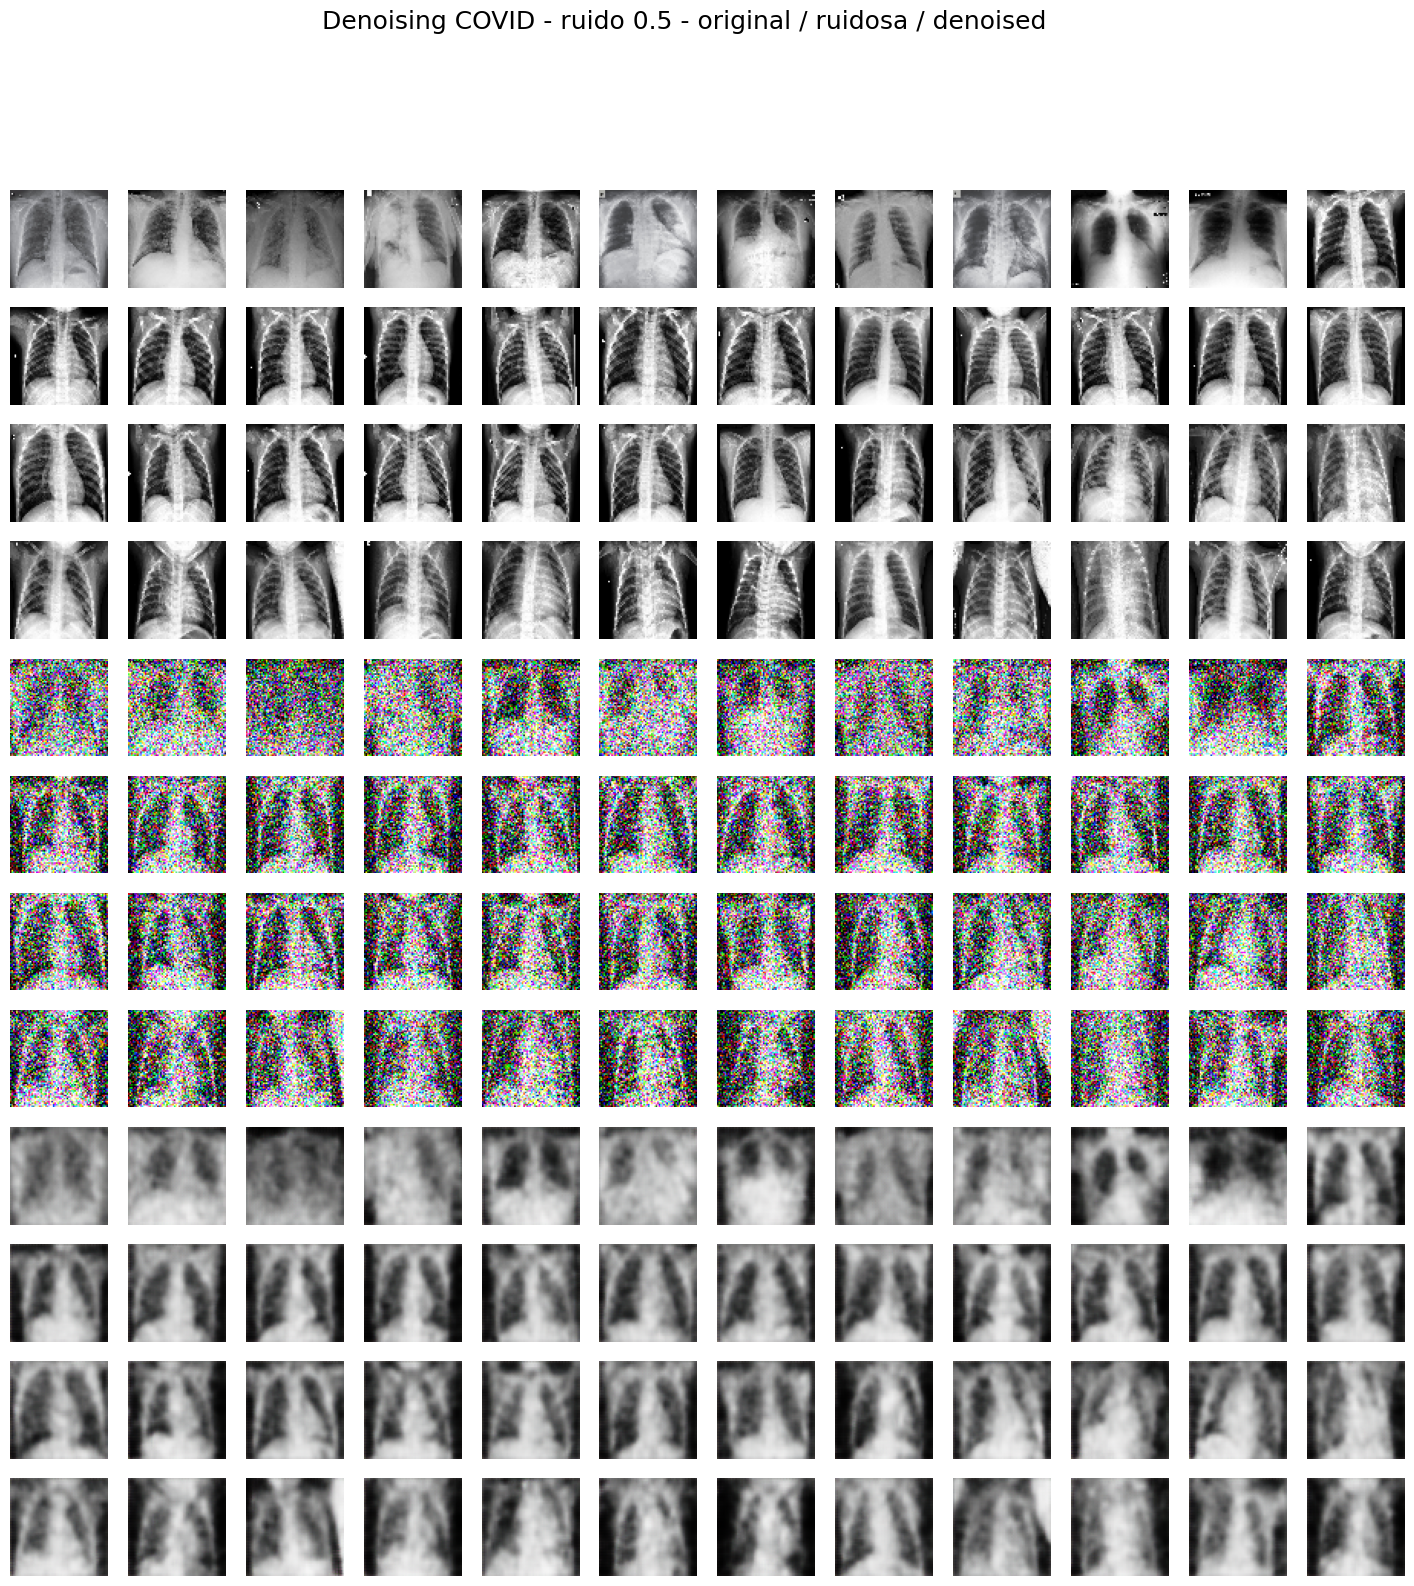


=== noise_factor 0.1 - modelo parches ===
ruidosa       PSNR:  20.49 dB   SSIM: 0.6376   MSE: 0.00895
denoised      PSNR:  24.95 dB   SSIM: 0.8255   MSE: 0.00346


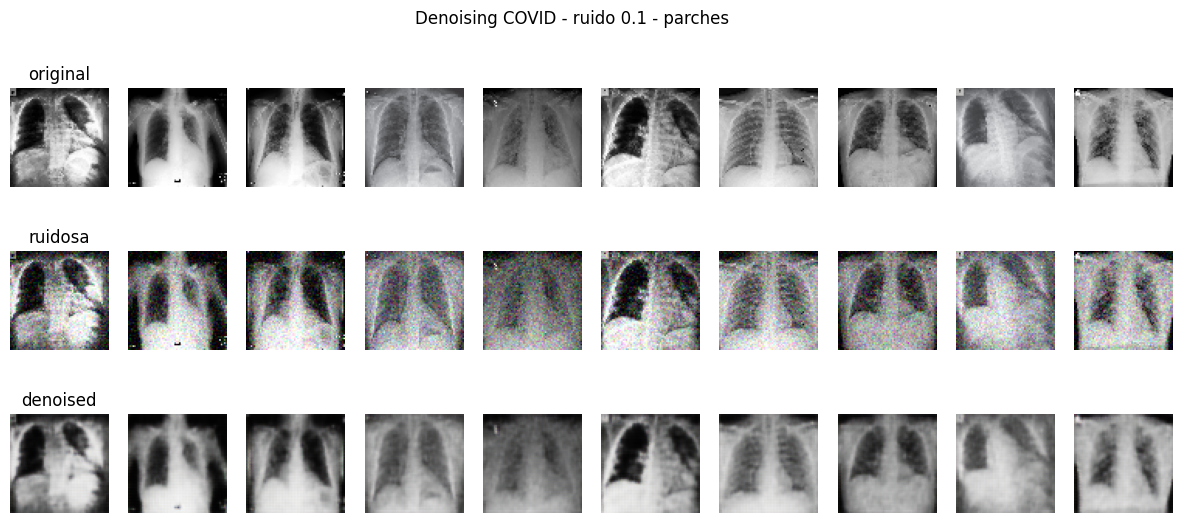

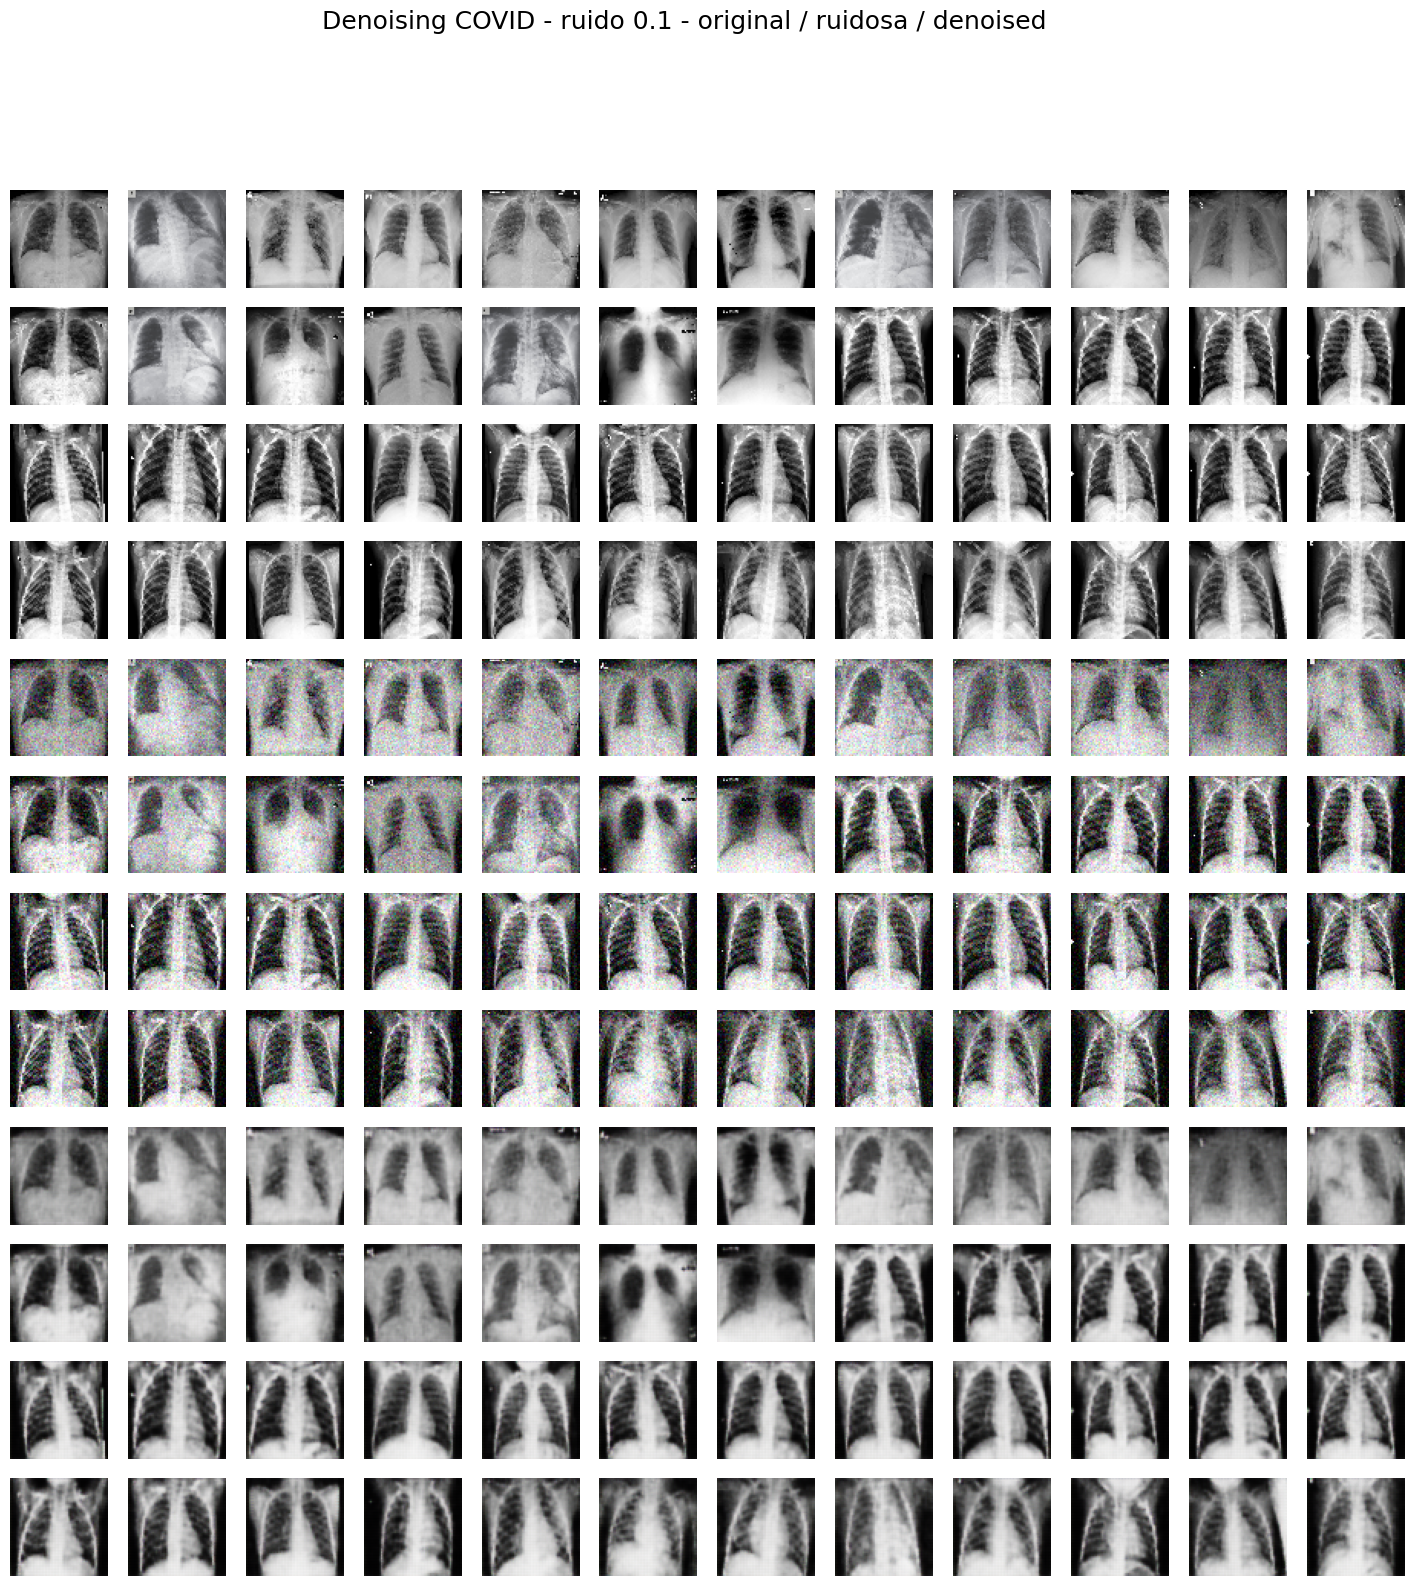

In [16]:
for nivel in NIVELES:
    m = mejores[nivel]
    modelo_final = modelos[m["nombre"]]
    x_test_n = x_test_ruido[nivel]
    pred_test = modelo_final.predict(x_test_n, verbose=0)

    print()
    print("=== noise_factor", nivel, "- modelo", m["estrategia"], "===")
    mostrar_metricas(x_test_n, x_test, "ruidosa")
    mostrar_metricas(pred_test, x_test, "denoised")

    # tripleta original ruidosa denoised
    plt.figure(figsize=(15,6))
    for i in range(10):
        ax = plt.subplot(3,10,i+1); plt.imshow(x_test[i]); plt.axis("off")
        if i==0: ax.set_title("original")
        ax = plt.subplot(3,10,i+11); plt.imshow(x_test_n[i]); plt.axis("off")
        if i==0: ax.set_title("ruidosa")
        ax = plt.subplot(3,10,i+21); plt.imshow(pred_test[i]); plt.axis("off")
        if i==0: ax.set_title("denoised")
    plt.suptitle("Denoising COVID - ruido " + str(nivel) + " - " + m["estrategia"])
    plt.savefig(f"/kaggle/working/triplet_ruido_{nivel}.pdf", format="pdf")
    plt.show()

    # grilla de 48 como la del profe, con 3 bloques
    n = 48
    r = np.random.randint(0, len(x_test)-n)
    imgs48 = x_test[r:r+n]
    noisy48 = x_test_n[r:r+n]
    den48 = modelo_final.predict(noisy48, verbose=0)
    rows, cols = 4, 12
    f = plt.figure(figsize=(cols*1.5, rows*1.5*3))
    for i in range(rows):
        for j in range(cols):
            k = i*cols + j
            f.add_subplot(rows*3, cols, (i*cols)+(j+1))                 # original
            plt.imshow(imgs48[k]); plt.axis("off")
            f.add_subplot(rows*3, cols, (rows*cols)+(i*cols)+(j+1))     # ruidosa
            plt.imshow(noisy48[k]); plt.axis("off")
            f.add_subplot(rows*3, cols, (2*rows*cols)+(i*cols)+(j+1))   # denoised
            plt.imshow(den48[k]); plt.axis("off")
    f.suptitle("Denoising COVID - ruido " + str(nivel) + " - original / ruidosa / denoised",
               fontsize=18)
    plt.savefig(f"/kaggle/working/grid48_ruido_{nivel}.pdf", format="pdf")
    plt.show()

## Conclusiones

Completar este apartado con los numeros reales despues de correr el cuaderno. Lo que conviene
discutir:

1. **El hallazgo principal: el cuello de botella pone el techo.** En la primera corrida vimos
   que con ruido 0.5 el modelo mejoraba la entrada hasta en 10 dB, pero con ruido 0.1 la
   empeoraba. La salida daba alrededor de 16 dB en ambos casos. Eso indica que el autoencoder,
   al comprimir 12.288 valores a 256, no puede entregar mas calidad que la que su cuello de
   botella permite: si la entrada esta peor, mejora; si esta mejor, empeora.

2. **Como lo atacamos.** Agregamos dos estrategias: salida residual (la red predice el ruido y
   se lo resta a la entrada, asi el piso pasa a ser la calidad de la entrada) y una red sin
   compresion estilo DnCNN (sin pooling ni capa densa). Comparar sus numeros contra la linea
   base del profesor.

3. **Cuanto cambia segun el nivel de ruido.** Comparar el PSNR y el SSIM del mismo modelo con
   0.5 y con 0.1. Si la diferencia es grande, decirlo: parte del techo lo pone la degradacion
   de la entrada y parte la arquitectura.

4. **Si el modelo sobreajusto.** Mirar las curvas: si la perdida de validacion sube mientras la
   de entrenamiento baja, el modelo esta memorizando. En ese caso conviene menos epocas o mas
   regularizacion.

5. **Ruido residual.** Si las imagenes reconstruidas todavia muestran ruido, decirlo. La
   rubrica de nivel sobresaliente pide imagenes sin ruido residual, pero tambien se valora que
   el analisis sea honesto.

6. **Por que funciona.** La explicacion del paper de Vincent: el modelo aprende la variedad
   donde viven las imagenes limpias y proyecta cualquier punto corrupto de vuelta sobre ella.
   El ruido es aleatorio y no se puede comprimir; la estructura de la radiografia si.

7. **Limitacion principal.** El dataset es pequeno (251 imagenes de train). Eso limita cuanto
   se puede mejorar sin importar la arquitectura que se use.

## Referencias

### Papers consultados (carpeta doc/Image Denoising)

1. Vincent, P., Larochelle, H., Bengio, Y., Manzagol, P.-A. (2008). Extracting and Composing
   Robust Features with Denoising Autoencoders. Technical Report 1316, Universite de Montreal.
   Paper fundacional del denoising autoencoder. De aqui sale la idea de entrenar con una
   entrada corrupta exigiendo la salida limpia, y la interpretacion geometrica: el modelo
   aprende a proyectar puntos de vuelta sobre la variedad (manifold) donde viven las imagenes
   limpias. Tambien establece que la fraccion de corrupcion es un hiperparametro que se debe
   calibrar, no un valor fijo.

2. Vincent, P. (2010). A Connection Between Score Matching and Denoising Autoencoders.
   Technical Report 1358, Universite de Montreal.
   Demuestra que un denoising autoencoder con ruido gaussiano esta aprendiendo el score
   (gradiente de la log-densidad) de la distribucion de los datos. Esto justifica de forma
   teorica el uso de ruido gaussiano que pide el enunciado del examen.

3. Nishio, M., Nagashima, C., Hirabayashi, S., Ohnishi, A., Sasaki, K., Sagawa, T.,
   Hamada, M., Yamashita, T. (2017). Convolutional auto-encoder for image denoising of
   ultra-low-dose CT. Heliyon, 3(8), e00393.
   Aplica exactamente nuestro caso pero en tomografias de dosis baja. Dos ideas que tomamos
   de aqui: entrenar con parches en lugar de imagenes completas (ellos extraen parches de
   28x28 y llegan a 100,000 pares de entrenamiento a partir de pocas imagenes), y usar una
   red convolucional sin capas de pooling, manteniendo el tamaño espacial con kernel 3x3 y
   padding de 1.

### Ejemplos de codigo consultados

4. Keras Team. Convolutional autoencoder for image denoising.
   https://github.com/keras-team/keras-io/blob/master/examples/vision/autoencoder.py
   Ejemplo oficial de Keras. Muestra el patron basico del autoencoder convolucional para
   denoising y la estrategia de entrenar primero limpio contra limpio y despues reentrenar
   ruidoso contra limpio.

5. Sarang, N. ImageDenoisingAutoencoder.
   https://github.com/nsarang/ImageDenoisingAutoencdoer
   Arquitectura tipo U-Net con conexiones skip por concatenacion en varios niveles, aumento
   de datos con ImageDataGenerator, recorte aleatorio para generar parches, y ruido con sigma
   variable por lote en lugar de un factor fijo.

6. Sarthak-22. Convolutional AutoEncoders for Denoising Images.
   https://github.com/Sarthak-22/Convolutional_AutoEncoders_for_Denoising_Images
   Implementacion en PyTorch con dos capas de convolucion en el encoder y dos transpuestas en
   el decoder, entrenada 100 epocas con MSE. Sirve como referencia de una arquitectura minima
   que ya produce resultados utiles.

7. Yadav, A. Denoising CIFAR-10.
   https://github.com/anushkayadav/Denoising_cifar10
   Compara tres enfoques sobre el mismo dataset y reporta PSNR y SSIM, lo que nos da una
   referencia numerica para saber que valores son realistas: autoencoder simple
   (PSNR 24.83, SSIM 0.868), autoencoder convolucional con conexiones skip simetricas
   (PSNR 28.25, SSIM 0.938) y DnCNN (PSNR 28.99, SSIM 0.947). De aqui tomamos dos ideas:
   las conexiones skip mejoran el PSNR en mas de 3 dB, y el max pooling puede ser perjudicial
   para tareas de restauracion, por lo que conviene probar convoluciones con stride 2.

### Material de clase

8. Paniagua, J. L. (2026). Semana 5: CNN Autoencoder con CIFAR-10. Universidad Autonoma de
   Occidente. Base de la arquitectura usada en este cuaderno: encoder y decoder con
   BatchNormalization, Dropout, LeakyReLU y conexion skip.